## Loan Approval Prediction — Data Cleaning
Dataset: `loan_data_1.csv` — 381 rows, 13 features including the target `Loan_Status`.

In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [198]:
import warnings
warnings.filterwarnings('ignore')

In [199]:
df = pd.read_csv('../Data/loan_data_1.csv', index_col = 0)

### Initial Inspection
Check shape, dtypes, null counts, and a sample of the data.

In [200]:
print("Total number of rows is: ", df.shape[0])
print(df.info())
print("Features are: \n", df.columns)

Total number of rows is:  381
<class 'pandas.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    str    
 1   Gender             376 non-null    str    
 2   Married            381 non-null    str    
 3   Dependents         373 non-null    str    
 4   Education          375 non-null    str    
 5   Self_Employed      360 non-null    str    
 6   ApplicantIncome    369 non-null    float64
 7   CoapplicantIncome  363 non-null    float64
 8   LoanAmount         373 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    str    
 12  Loan_Status        381 non-null    str    
dtypes: float64(5), str(8)
memory usage: 38.8 KB
None
Features are: 
 Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employe

In [201]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333.0,1516.0,95.0,360.0,1.0,Urban,Y


### Descriptive Statistics
Summary stats for numerical features to spot range issues and skew before imputation.

In [202]:
df[['ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History']].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,369.000000,363.000000,373.000000,370.000000,351.000000
mean,3563.422764,1267.005289,104.914209,340.864865,0.837607
std,1427.371257,2388.048316,28.484822,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2583.000000,0.000000,90.000000,360.000000,1.000000
50%,3326.000000,830.000000,110.000000,360.000000,1.000000
75%,4226.000000,2008.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


Checking unique values for `Dependents` (has a `'3+'` string category) and `Credit_History` (binary: 0/1 with nulls).

In [203]:
print(df["Dependents"].unique())
print(df["Credit_History"].unique())

<StringArray>
['1', '0', '2', '3+', nan]
Length: 5, dtype: str
[ 1. nan  0.]


### Credit History Null Analysis
`Credit_History` has 30 missing values. Before imputing, checking whether missing values correlate with loan rejection — this determines the right imputation strategy.

Result: 26 approved vs 4 rejected among null rows → missingness leans toward approval, so **mode imputation (1.0) is appropriate**.

In [204]:
raw = pd.read_csv('../Data/loan_data_1.csv', index_col=0)
print(raw[raw['Credit_History'].isna()]['Loan_Status'].value_counts())

Loan_Status
Y    26
N     4
Name: count, dtype: int64


### Null Imputation
- **Numerical** (`ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`): median, since these are right-skewed (outliers would pull the mean).
- **Categorical / binary** (`Loan_Amount_Term`, `Credit_History`, `Gender`, `Dependents`, `Education`, `Self_Employed`): mode.

In [205]:
df['ApplicantIncome'] = df['ApplicantIncome'].fillna(df['ApplicantIncome'].median())
df['CoapplicantIncome'] = df['CoapplicantIncome'].fillna(df['CoapplicantIncome'].median())
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [206]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [207]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome      float64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

### Encoding Categorical Features
Binary categories are encoded as 0/1 integer flags. `Loan_Status` (target) is renamed to `Is_Loan_Approved` for clarity.

In [208]:
df['Is_Male'] = (df['Gender'] == 'Male').astype(int)
df.drop('Gender', axis=1, inplace=True)

In [209]:
df['Is_Married'] = (df['Married'] == 'Yes').astype(int)
df.drop('Married', axis=1, inplace=True)

In [210]:
df['Is_Education'] = (df['Education'] == 'Graduate').astype(int)
df.drop('Education', axis=1, inplace=True)

In [211]:
df['Is_Self_Employed'] = (df['Self_Employed'] == 'Yes').astype(int)
df.drop('Self_Employed', axis=1, inplace=True)

In [212]:
df['Is_Loan_Approved'] = (df['Loan_Status'] == 'Y').astype(int)
df.drop('Loan_Status', axis=1, inplace=True)

`Dependents` has a `'3+'` string value — replacing it with `3` and casting to int so the column is fully numeric.

In [213]:
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(int)

`Property_Area` has 3 categories (Rural, Semiurban, Urban) — one-hot encoded with `drop_first=True` to avoid multicollinearity.

In [214]:
dummies = pd.get_dummies(
    df['Property_Area'],
    prefix='Property_Area',
    drop_first=True,
    dtype=int
)

df = pd.concat([df, dummies], axis=1)

df.drop('Property_Area', axis=1, inplace=True)

In [215]:
df.dtypes

Loan_ID                        str
Dependents                   int64
ApplicantIncome            float64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Is_Male                      int64
Is_Married                   int64
Is_Education                 int64
Is_Self_Employed             int64
Is_Loan_Approved             int64
Property_Area_Semiurban      int64
Property_Area_Urban          int64
dtype: object

`Loan_ID` is a unique identifier with no predictive value — dropping it.

In [216]:
df = df.drop(columns=['Loan_ID'])

Final check — confirming `Property_Area` is gone and all expected columns are present.

In [217]:
print('Property_Area' in df.columns)
print(df.columns.tolist())

False
['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Is_Male', 'Is_Married', 'Is_Education', 'Is_Self_Employed', 'Is_Loan_Approved', 'Property_Area_Semiurban', 'Property_Area_Urban']


## Exploratory Data Analysis

In [218]:
import matplotlib.pyplot as plt
import seaborn as sns

In [219]:
df.columns

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Is_Male', 'Is_Married',
       'Is_Education', 'Is_Self_Employed', 'Is_Loan_Approved',
       'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='str')

Define categorical and continuous feature groups for separate treatment in visualizations.

In [220]:
categorical_features = ['Dependents', 'Credit_History', 'Is_Male', 'Is_Married', 'Is_Education', 'Is_Self_Employed', 'Is_Loan_Approved', 'Property_Area_Semiurban', 'Property_Area_Urban']

Continuous_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

### Categorical Feature Distributions
Bar charts showing value counts for each categorical feature. Key observations: dataset is male-heavy, most applicants are graduates, `Credit_History` is dominated by 1.0, and the target `Is_Loan_Approved` is imbalanced (~270 approved vs ~110 rejected).

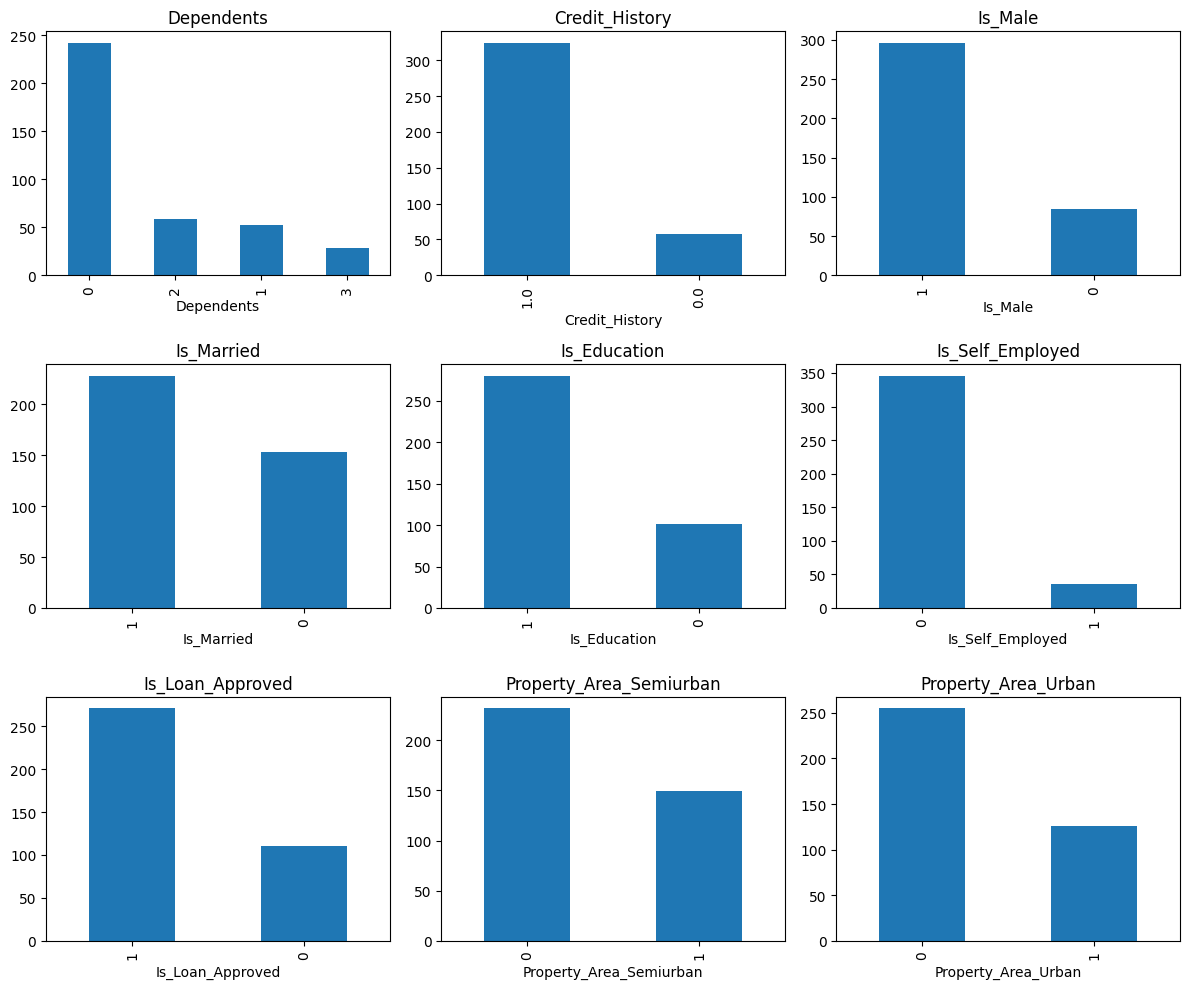

In [221]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()
for ind, feature in enumerate(categorical_features):
    df[feature].value_counts().plot(kind='bar', ax=axes[ind])
    axes[ind].set_title(feature)
plt.tight_layout()
plt.show()

### Continuous Feature Distributions
Histograms showing distribution shape. All four features are right-skewed with outliers — log transform may be needed before model training.

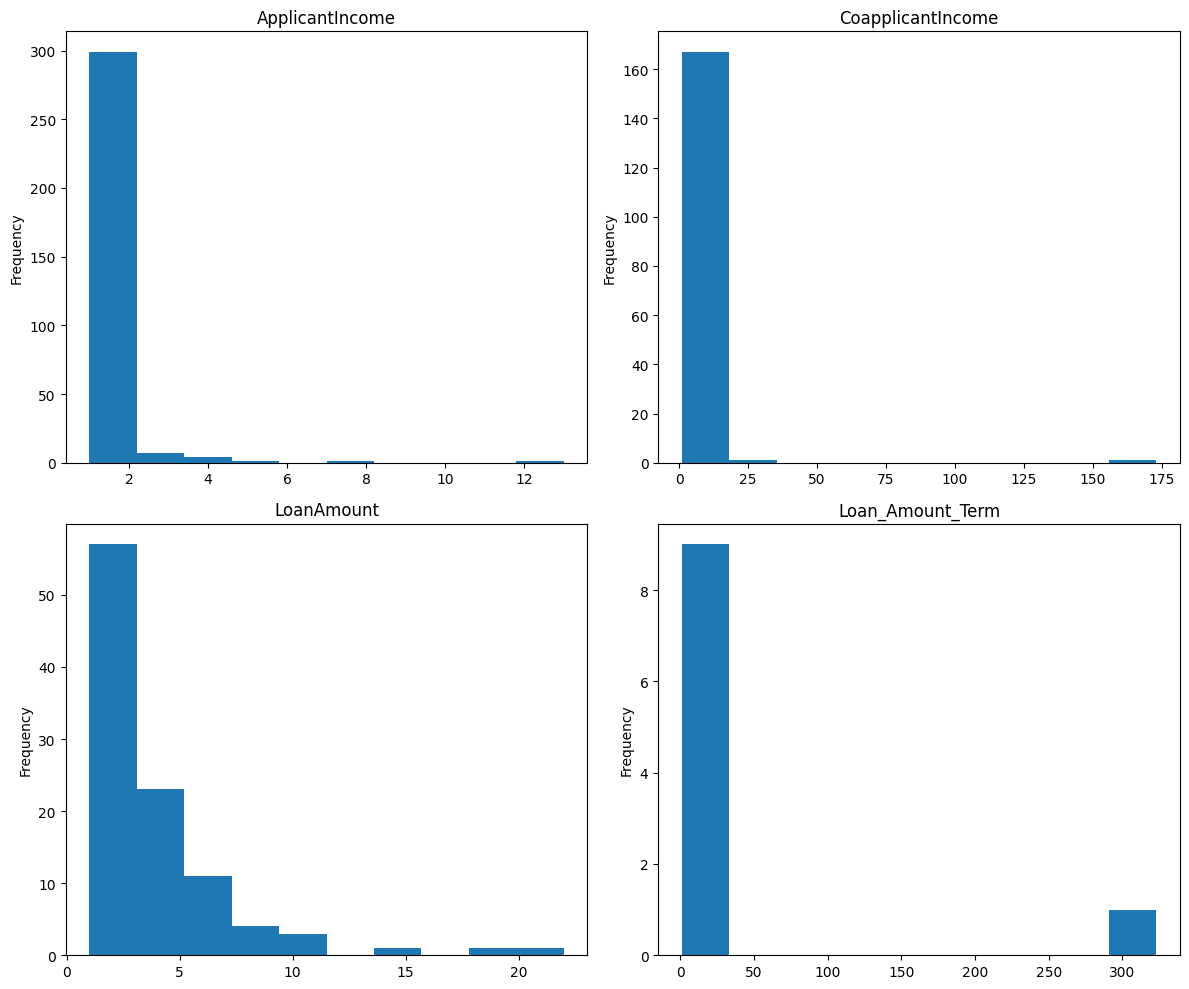

In [222]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ind, feature in enumerate(Continuous_features):
    df[feature].value_counts().plot(kind='hist', ax=axes[ind])
    axes[ind].set_title(feature)
plt.tight_layout()
plt.show()

Boxplots confirming outliers in all continuous features, particularly `CoapplicantIncome`.

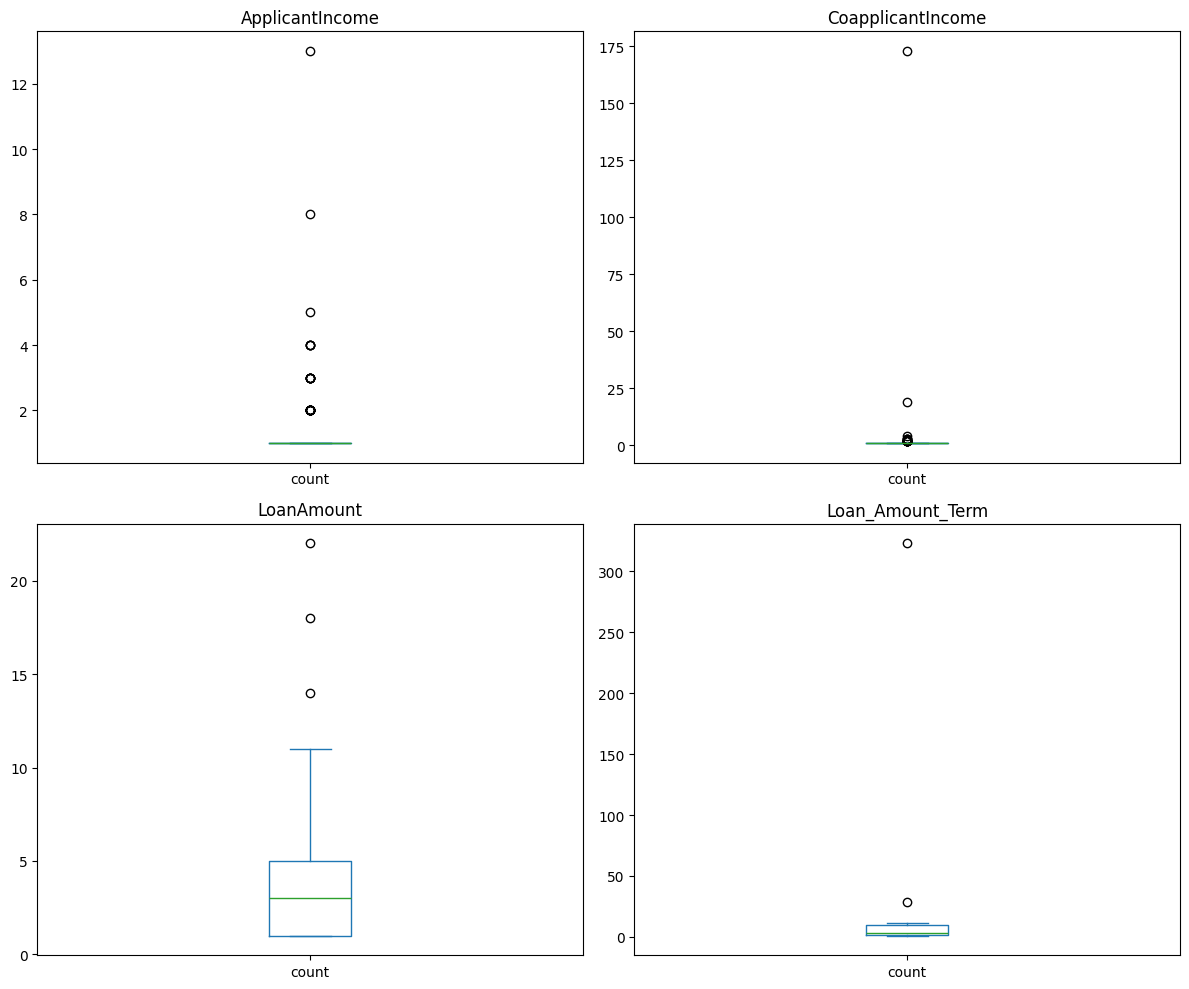

In [223]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ind, feature in enumerate(Continuous_features):
    df[feature].value_counts().plot(kind='box', ax=axes[ind])
    axes[ind].set_title(feature)
plt.tight_layout()
plt.show()

### Continuous Features vs Target
Boxplots grouped by `Is_Loan_Approved` (0 vs 1). Distributions heavily overlap across all four features — none are strong individual separators of the target.

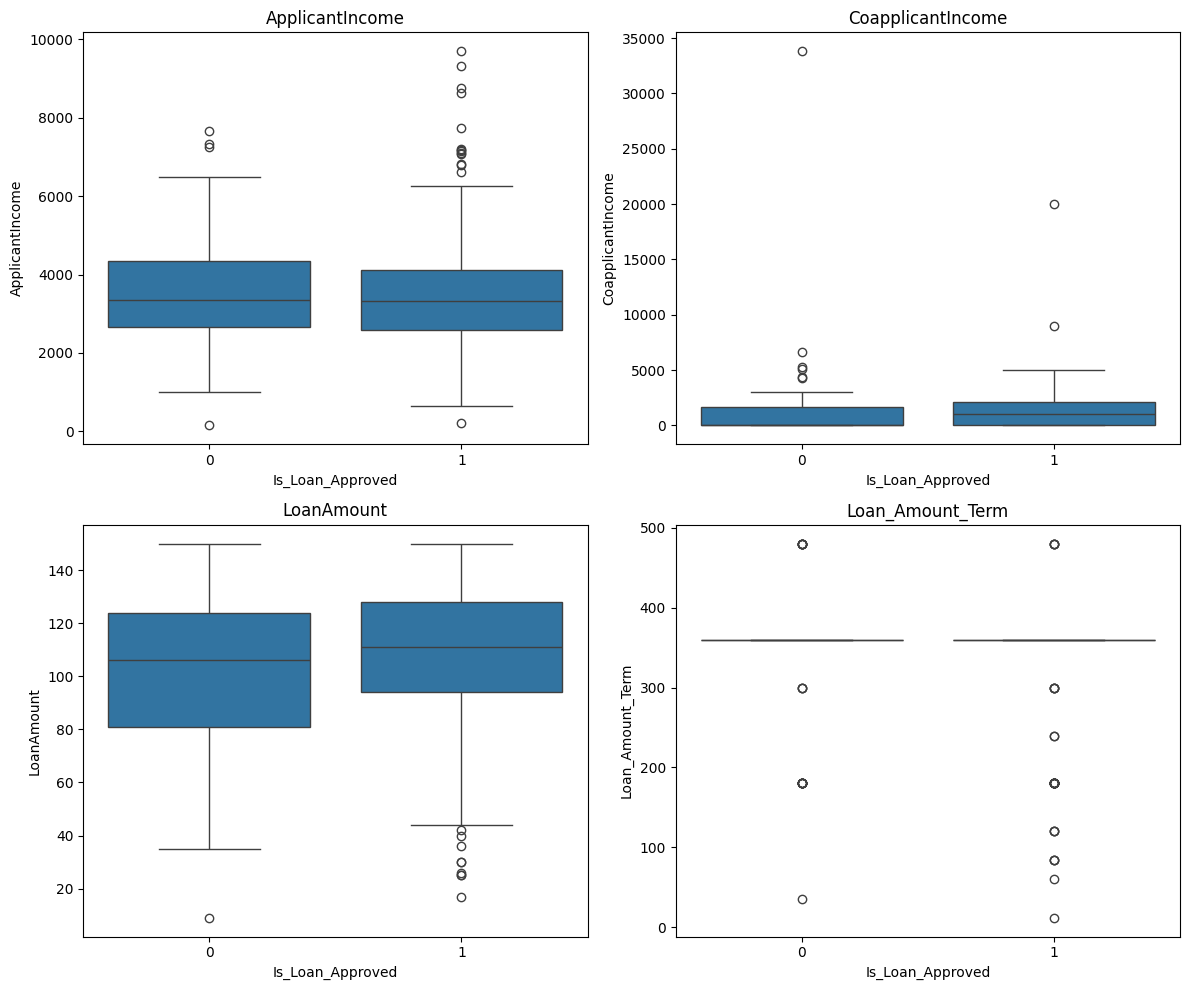

In [224]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ind, feature in enumerate(Continuous_features):
    sns.boxplot(data=df, x='Is_Loan_Approved', y=feature, ax=axes[ind])
    axes[ind].set_title(feature)
plt.tight_layout()
plt.show()

### Correlation Heatmap (Pearson)
Pearson correlation across continuous features and target. All continuous features have near-zero correlation with `Is_Loan_Approved` (max 0.05). `ApplicantIncome` and `CoapplicantIncome` show mild negative correlation (-0.23) with each other.

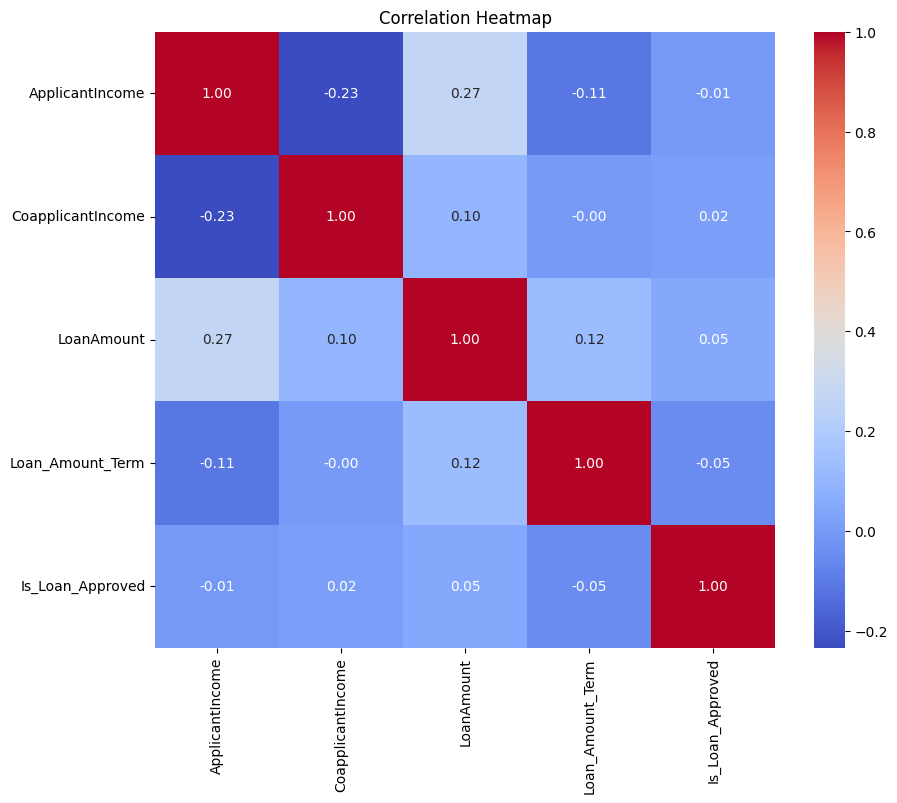

In [225]:
corr_matrix = df[Continuous_features + ['Is_Loan_Approved']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Isolated correlation of each continuous feature with the target — confirms all are weak predictors individually.

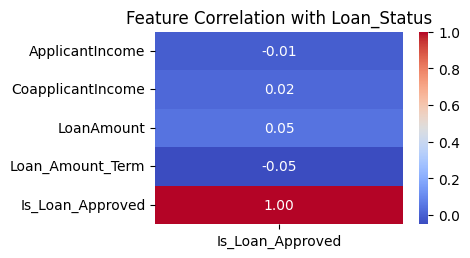

In [226]:
target_corr = df[Continuous_features + ['Is_Loan_Approved']].corr()[['Is_Loan_Approved']]

plt.figure(figsize=(4, len(target_corr) * 0.5))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Loan_Status')
plt.show()

### Chi-Square Test — Categorical Features vs Target
Chi-square test measures association between each categorical feature and `Is_Loan_Approved`. Features with p-value < 0.05 are statistically significant.

Results: `Credit_History` (p≈0.00) and `Property_Area_Semiurban` (p=0.004) are significant. `Is_Married` (p=0.09) is borderline. All others are dropped.

In [227]:
from scipy.stats import chi2_contingency

for feature in categorical_features:
    if feature == 'Is_Loan_Approved':
        continue
    contingency_table = pd.crosstab(df[feature], df['Is_Loan_Approved'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"{feature}: p-value = {p:.4f}")

Dependents: p-value = 0.8702
Credit_History: p-value = 0.0000
Is_Male: p-value = 0.7945
Is_Married: p-value = 0.0911
Is_Education: p-value = 0.5490
Is_Self_Employed: p-value = 0.8771
Property_Area_Semiurban: p-value = 0.0037
Property_Area_Urban: p-value = 0.6101


## Feature Selection & Model Training
### Model 1 — Selected Features Only
Features chosen based on Chi-square results: `Credit_History`, `Property_Area_Semiurban`, `Is_Married`.

In [228]:
X = df[['Credit_History', 'Property_Area_Semiurban', 'Is_Married']]
y = df['Is_Loan_Approved']

`class_weight='balanced'` used to counter target imbalance (~70% approved). 80/20 train-test split with `random_state=42` for reproducibility.

In [229]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(class_weight = 'balanced')
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

In [230]:
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {actual}, Predicted: {predicted}")

Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 1
Actual: 1, Predicted: 0
Actual: 0, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 1


Model 1 results: 81.8% accuracy but class 0 recall = 0.33 — model misses 67% of rejections. The 3 features lack sufficient signal to identify rejected loans.

In [231]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.4f}%")
print(classification_report(y_test, y_pred))

Accuracy: 81.8182%
              precision    recall  f1-score   support

           0       1.00      0.33      0.50        21
           1       0.80      1.00      0.89        56

    accuracy                           0.82        77
   macro avg       0.90      0.67      0.69        77
weighted avg       0.85      0.82      0.78        77



### Model 2 — All Features
Retrain with all features to verify whether the weak continuous features add any signal beyond the 3 selected ones.

In [232]:
x = df.drop(columns = 'Is_Loan_Approved')
y = df['Is_Loan_Approved']

In [233]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
model = LogisticRegression(class_weight = 'balanced')
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

In [234]:
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {actual}, Predicted: {predicted}")

Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 1


Model 2 results: 75.3% accuracy but class 0 recall improves to 0.52 — the model is now catching more rejections at the cost of overall accuracy. More honest representation of model performance given class imbalance.

In [235]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.4f}%")
print(classification_report(y_test, y_pred))

Accuracy: 75.3247%
              precision    recall  f1-score   support

           0       0.55      0.52      0.54        21
           1       0.82      0.84      0.83        56

    accuracy                           0.75        77
   macro avg       0.69      0.68      0.68        77
weighted avg       0.75      0.75      0.75        77

